In [ ]:
# Imports
import matplotlib.pyplot as plt
%matplotlib inline

import numpy as np
import pandas as pd

In [ ]:
# ML Imports
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [ ]:
# Data reading
def read_data(path):
    """To read a csv file and return a pandas df"""
    df = pd.read_csv(path)
    return df

In [26]:
from dotenv import load_dotenv
import os

load_dotenv()

student_performance_csv_path = os.getenv('student_performance_csv')

In [27]:
df = read_data(student_performance_csv_path)
df

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0
9998,9,97,Yes,7,0,95.0


In [ ]:
# Data transform -> Here 'Extracurricular Activities' are a data with established orders : Yes | No. 
df['Extracurricular Activities'] = df['Extracurricular Activities'].astype('category')
df['Extracurricular Activities'] = df['Extracurricular Activities'].cat.codes # To assign 0 or 1. 
df


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,1,4,2,23.0
9996,7,64,1,8,5,58.0
9997,6,83,1,8,5,74.0
9998,9,97,1,7,0,95.0


In [ ]:
# We ensure that there´s no invalid data
df.isnull().sum()

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

In [ ]:
# We assign the values of 'X'.
X = df.drop(columns='Performance Index')
X

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
0,7,99,1,9,1
1,4,82,0,4,2
2,8,51,1,7,2
3,5,52,1,5,2
4,7,75,0,8,5
...,...,...,...,...,...
9995,1,49,1,4,2
9996,7,64,1,8,5
9997,6,83,1,8,5
9998,9,97,1,7,0


In [31]:
y = df['Performance Index']
y

0       91.0
1       65.0
2       45.0
3       36.0
4       66.0
        ... 
9995    23.0
9996    58.0
9997    74.0
9998    95.0
9999    64.0
Name: Performance Index, Length: 10000, dtype: float64

In [ ]:
# data set split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [ ]:
# Prediction
lr = LinearRegression()
lr.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[2.86,1.02,0.58,0.48,0.19]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['Hours Studied','Previous Scores','Extracurricular Activities', 'Sleep Hours','Sample Question Papers Practiced']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-33.84
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)


In [ ]:
# Theta (b) Parameter
lr.intercept_

np.float64(-33.836543807141716)

In [ ]:
#  Theta_1 Parameter
lr.coef_

array([2.85895223, 1.01551979, 0.58171285, 0.47967676, 0.19039416])

In [ ]:
# Prediction.
y_pred_train = lr.predict(x_train)

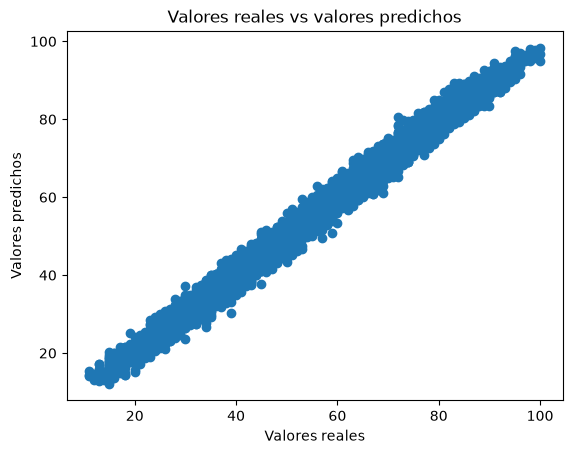

In [ ]:
plt.scatter(y_train, y_pred_train)
plt.xlabel('Real values')
plt.ylabel('Predicted Values')
plt.title('Real values vs Predicted Values')
plt.show()

In [ ]:
# MSE y R^2 coef
mse = mean_squared_error(y_train, y_pred_train)
r2 = r2_score(y_train, y_pred_train)
print('Mean Square error:', mse)
print('R2 Coef:', r2)
#

Error cuadrático medio: 4.193473712437295
Coeficiente de determinación: 0.9886221887978632


In [ ]:
# Prediction with test values
y_pred_test = lr.predict(x_test)

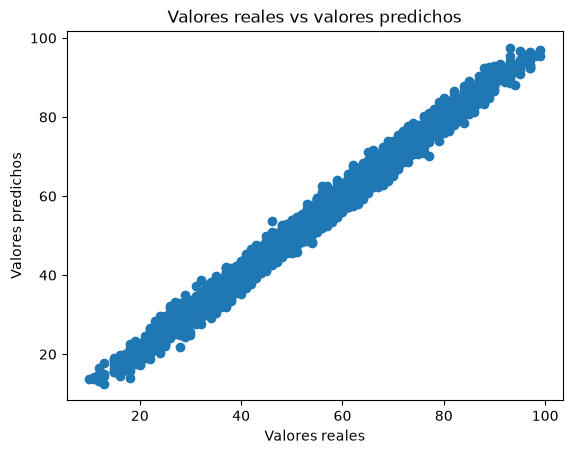

In [ ]:
plt.scatter(y_test, y_pred_test)
plt.xlabel('Real values')
plt.ylabel('Predicted Values')
plt.title('Real values vs Predicted Values')
plt.show()

In [ ]:
# MSE y  R2 coef
mse = mean_squared_error(y_train, y_pred_train)
r2 = r2_score(y_train, y_pred_train)
print('Mean Square error:', mse)
print('R2 Coef:', r2)

Error cuadrático medio: 4.193473712437295
Coeficiente de determinación: 0.9886221887978632


In [ ]:
new_example = pd.DataFrame({
    'Hours Studied': [8],
    'Previous Scores': [85],
    'Extracurricular Activities': [1], # 0 for No, 1 for Yes
    'Sleep Hours': [7],
    'Sample Question Papers Practiced': [4]
})

predicted_performance = lr.predict(new_example)

print(f"The predicted performance index for the new example is: {predicted_performance[0]:.2f}")

El índice de rendimiento predicho para el nuevo ejemplo es: 80.06
